# Open-vocabulary Detection with Grounding DINO Tiny

Model: `IDEA-Research/grounding-dino-tiny`

This notebook demonstrates open-vocabulary object detection with custom text queries (class names) and visualizes predicted boxes.


In [1]:
%pip -q install torch torchvision transformers pillow matplotlib requests setuptools

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import transformers
import transformers.utils as hf_utils

# Compatibility guard: some environments have incompatible flash-attn binaries.
# Disabling it avoids import failures for Grounding DINO.
hf_utils.is_flash_attn_2_available = lambda: False

from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

MODEL_ID = 'IDEA-Research/grounding-dino-tiny'
device = 'cuda' 
device

'cuda'

In [3]:
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(device)
model.eval()
print(f'Loaded model: {MODEL_ID} on {device}')

/opt/conda/envs/vlmflow/lib/python3.10/site-packages/torch/utils/cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Loaded model: IDEA-Research/grounding-dino-tiny on cuda


In [4]:
def build_text_prompt(labels):
    """Convert a list of labels into Grounding DINO text prompt format.
    Important: lower-case + period per label.
    """
    normalized = []
    for label in labels:
        label = label.strip().lower()
        if not label:
            continue
        if not label.endswith('.'):
            label += '.'
        normalized.append(label)
    return ' '.join(normalized)


@torch.no_grad()
def run_open_vocab_detection(image, text_prompt, threshold=0.35, text_threshold=0.25):
    inputs = processor(images=image, text=text_prompt, return_tensors='pt').to(device)
    outputs = model(**inputs)

    results = processor.post_process_grounded_object_detection(
        outputs=outputs,
        input_ids=inputs.input_ids,
        threshold=threshold,
        text_threshold=text_threshold,
        target_sizes=[image.size[::-1]]
    )
    return results[0]


def _extract_text_labels(result):
    # Newer versions expose text labels in text_labels; keep fallback for compatibility.
    if 'text_labels' in result:
        return result['text_labels']
    return result['labels']


def visualize_detections(image, result):
    image_np = np.array(image)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(image_np)

    boxes = result['boxes']
    scores = result['scores']
    labels = _extract_text_labels(result)

    for box, score, label in zip(boxes, scores, labels):
        x0, y0, x1, y1 = box.tolist()
        w, h = x1 - x0, y1 - y0

        rect = patches.Rectangle((x0, y0), w, h, linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)

        txt = f"{label}: {float(score):.3f}"
        ax.text(
            x0,
            max(y0 - 4, 0),
            txt,
            color='black',
            fontsize=10,
            bbox=dict(facecolor='lime', alpha=0.7, edgecolor='none', pad=1.5)
        )

    ax.set_axis_off()
    ax.set_title('Grounding DINO Tiny - Open-vocabulary Detection')
    plt.show()

    return len(boxes)


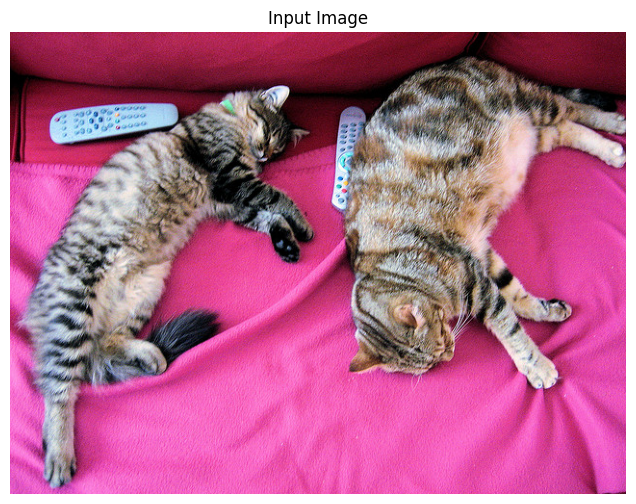

In [5]:
# Example image from COCO.
# You can replace this with your own local image:
# image = Image.open('/path/to/your_image.jpg').convert('RGB')

image_url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(image_url, stream=True).raw).convert('RGB')

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.title('Input Image')
plt.show()

Text prompt: cat. remote control. sofa. lamp.
Detected objects: 5
- cat: 0.8098
- cat: 0.8343
- sofa: 0.6283
- remote control: 0.5085
- remote control: 0.4467


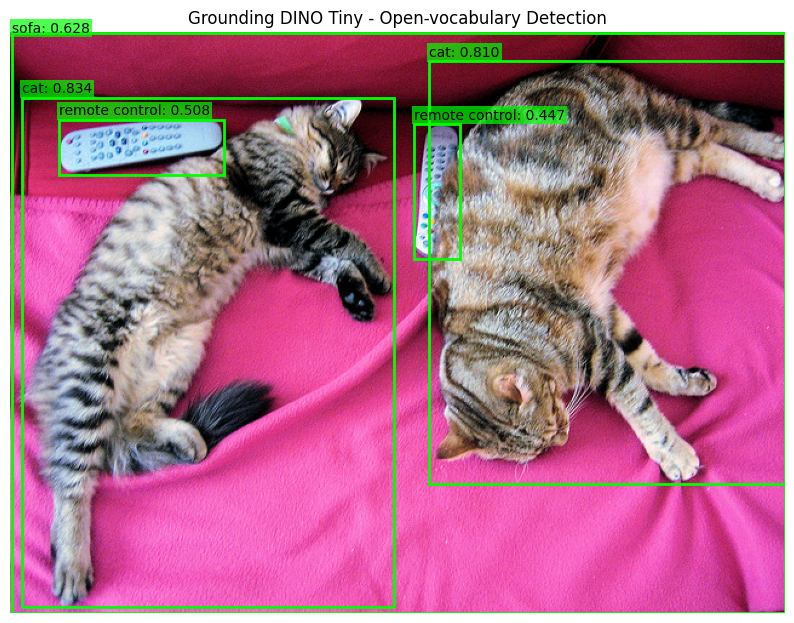

In [6]:
# Open-vocabulary labels (edit freely)
candidate_labels = ['cat', 'remote control', 'sofa', 'lamp']
text_prompt = build_text_prompt(candidate_labels)
print('Text prompt:', text_prompt)

result = run_open_vocab_detection(
    image=image,
    text_prompt=text_prompt,
    threshold=0.35,
    text_threshold=0.25
)

labels = _extract_text_labels(result)
print('Detected objects:', len(result['boxes']))
for s, l in zip(result['scores'], labels):
    print(f'- {l}: {float(s):.4f}')

_ = visualize_detections(image, result)

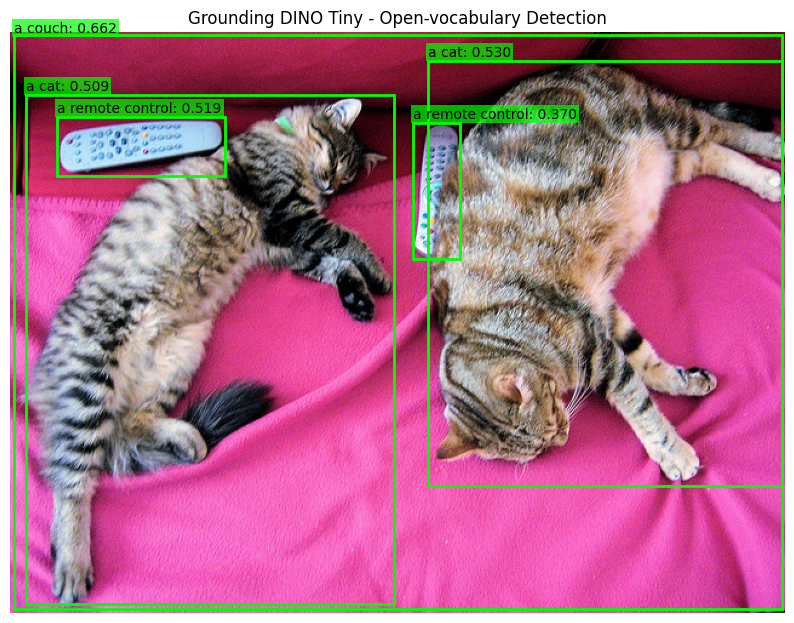

In [7]:
# Optional: raw text prompt mode
# Note: Grounding DINO works best when each query is lower-case and ends with a period.

custom_text_prompt = 'a cat. a remote control. a couch.'
result_custom = run_open_vocab_detection(image, custom_text_prompt, threshold=0.35, text_threshold=0.25)
_ = visualize_detections(image, result_custom)